In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
from src.data_loader import DataLoader
from src.preprocessing import TimeSeriesPreprocessor
from src.evaluation import Evaluator
from src.arima_model import TimeSeriesARIMA
from src.visualization import Visualizer
from src.lstm_model import TimeSeriesLSTM


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
files = {
    "TSLA": "data/processed/TSLA_processed.csv",
    "SPY": "data/processed/SPY_processed.csv",
    "BND": "data/processed/BND_processed.csv"
}

raw_data = {}

for name, path in files.items():

    loader = DataLoader(path)
    df = loader.load_data()

    raw_data[name] = df

    print(f"{name} loaded -> {df.shape}")

In [ ]:
preprocessor = TimeSeriesPreprocessor()

clean_data = {}

for name, df in raw_data.items():

    df = preprocessor.clean_data(df)

    clean_data[name] = df

    print(f"{name} cleaned -> {df.shape}")

ValueError: could not convert string to float: 'TSLA'

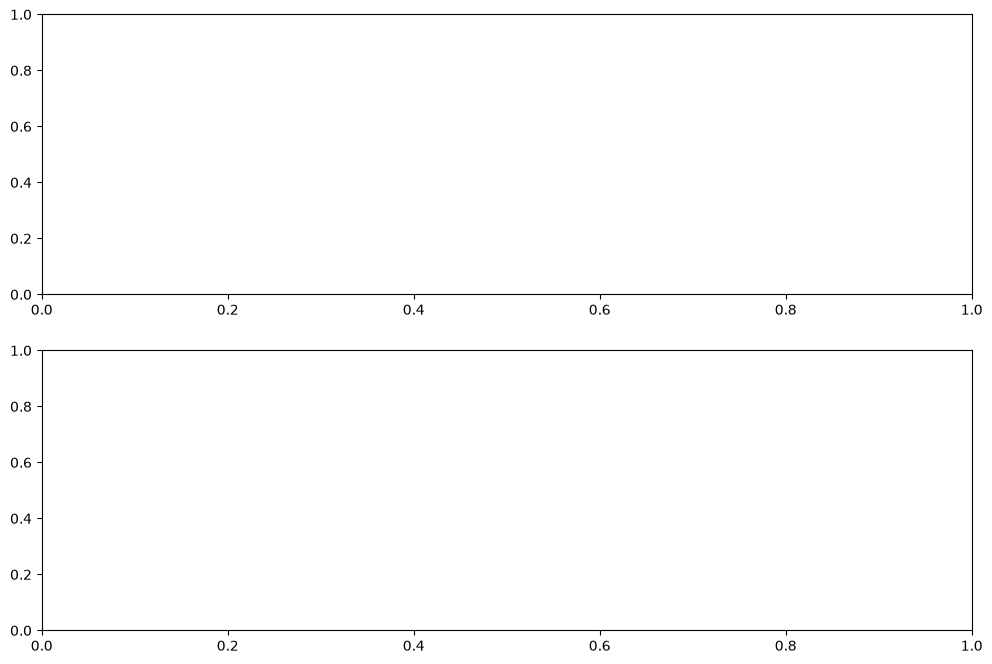

In [ ]:
train_data = {}
test_data = {}

for name, df in clean_data.items():

    train, test = preprocessor.train_test_split(df)

    train_data[name] = train
    test_data[name] = test

    print(f"{name}")
    print("Train:", train.shape, "Test:", test.shape)

In [ ]:
arima_train = {}
arima_test = {}

for name in clean_data.keys():

    arima_train[name] = train_data[name]["Daily_Return"].dropna()
    arima_test[name] = test_data[name]["Daily_Return"].dropna()

    print(f"{name} ARIMA ready")

TypeError: train_arima() missing 1 required positional argument: 'order'

In [ ]:
lstm_train = {}
lstm_test = {}
scalers = {}

for name in clean_data.keys():

    train_scaled, test_scaled, scaler = preprocessor.scale_close(
        train_data[name],
        test_data[name],
        col="Close"
    )

    lstm_train[name] = train_scaled
    lstm_test[name] = test_scaled
    scalers[name] = scaler

    print(f"{name} scaled for LSTM")

NameError: name 'forecast_arima' is not defined

In [ ]:
window = 60

lstm_sequences = {}

for name in clean_data.keys():

    X_train, y_train = preprocessor.create_sequences(
        lstm_train[name],
        window
    )

    X_test, y_test = preprocessor.create_sequences(
        np.concatenate([lstm_train[name][-window:], lstm_test[name]]),
        window
    )

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    lstm_sequences[name] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test
    }

    print(f"{name} sequences created")

In [ ]:
summary = []

for name in clean_data.keys():

    summary.append({
        "Dataset": name,
        "Train Shape": train_data[name].shape,
        "Test Shape": test_data[name].shape,
        "ARIMA Target": "Daily_Return",
        "LSTM Target": "Close (Scaled)"
    })

import pandas as pd
pd.DataFrame(summary)

In [ ]:
arima_model = TimeSeriesARIMA()
evaluator = Evaluator()
viz = Visualizer()

In [ ]:
arima_results = {}
comparison = []

In [ ]:
for name in arima_train.keys():

    print("\n" + "="*70)
    print(f"Dataset: {name}")
    print("="*70)

    train = arima_train[name]
    test = arima_test[name]

    # -----------------------------
    # Grid Search ARIMA
    # -----------------------------
    model, order = arima_model.grid_search(train)

    print("Best Order:", order)

    # -----------------------------
    # Forecast Returns
    # -----------------------------
    forecast = arima_model.forecast(len(test))

    forecast = pd.Series(forecast, index=test.index)

    # -----------------------------
    # Convert Return → Close Price
    # -----------------------------
    last_close = train_data[name]["Close"].iloc[-1]

    predicted_close = []
    current = last_close

    for r in forecast:

        current = current * (1 + r)
        predicted_close.append(current)

    predicted_close = pd.Series(
        predicted_close,
        index=test_data[name]["Close"].index
    )

    actual_close = test_data[name]["Close"]

    # -----------------------------
    # Evaluation on Close Price
    # -----------------------------
    mae, rmse, mape = evaluator.metrics(
        actual_close,
        predicted_close
    )

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)

    # -----------------------------
    # Save results
    # -----------------------------
    arima_results[name] = {
        "model": model,
        "order": order,
        "forecast": predicted_close,
        "actual": actual_close,
        "mae": mae,
        "rmse": rmse,
        "mape": mape
    }

    comparison.append({
        "Dataset": name,
        "Model": "ARIMA",
        "Order": order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

    # -----------------------------
    # Plot
    # -----------------------------
    viz.plot_forecast(
        actual_close,
        predicted_close,
        f"{name} ARIMA Forecast"
    )

In [ ]:
comparison_df = pd.DataFrame(comparison)

comparison_df

In [ ]:
comparison_df.to_csv(
    "outputs/arima_results.csv",
    index=False
)

print("ARIMA results saved.")

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

for name, result in arima_results.items():

    joblib.dump(
        result["model"],
        f"models/{name}_ARIMA.pkl"
    )

    print(f"Saved {name} ARIMA model")

In [ ]:
best = comparison_df.sort_values("RMSE").iloc[0]

print("="*60)
print("BEST ARIMA MODEL")
print("="*60)
print(best)

In [ ]:
lstm_builder = TimeSeriesLSTM()
evaluator = Evaluator()
viz = Visualizer()

In [ ]:
lstm_results = []
lstm_models = {}

In [ ]:
EPOCHS = 30
BATCH_SIZE = 32

for name in lstm_sequences.keys():

    print("\n" + "="*70)
    print(f"LSTM Training: {name}")
    print("="*70)

    X_train = lstm_sequences[name]["X_train"]
    y_train = lstm_sequences[name]["y_train"]

    X_test = lstm_sequences[name]["X_test"]
    y_test = lstm_sequences[name]["y_test"]

    # -------------------------
    # Build Model
    # -------------------------
    model = lstm_builder.build_model(
        input_shape=(X_train.shape[1], 1)
    )

    # -------------------------
    # Train
    # -------------------------
    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=1
    )

    # -------------------------
    # Predict
    # -------------------------
    predictions = model.predict(X_test, verbose=0)

    # -------------------------
    # Inverse Transform
    # -------------------------
    scaler = scalers[name]

    predictions_close = scaler.inverse_transform(predictions)
    actual_close = scaler.inverse_transform(y_test.reshape(-1, 1))

    # -------------------------
    # Metrics
    # -------------------------
    mae, rmse, mape = evaluator.metrics(
        actual_close,
        predictions_close
    )

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)

    # -------------------------
    # Store
    # -------------------------
    lstm_results.append({
        "Dataset": name,
        "Model": "LSTM",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

    lstm_models[name] = model

    # -------------------------
    # Plot
    # -------------------------
    viz.plot_forecast(
        actual_close,
        predictions_close,
        f"{name} LSTM Forecast"
    )

In [ ]:
lstm_df = pd.DataFrame(lstm_results)

lstm_df

In [ ]:
os.makedirs("outputs", exist_ok=True)

lstm_df.to_csv(
    "outputs/lstm_results.csv",
    index=False
)

print("LSTM metrics saved")

In [ ]:
import os

os.makedirs("models", exist_ok=True)

for name, model in lstm_models.items():

    model.save(f"models/{name}_LSTM.keras")

    print(f"Saved {name} LSTM model")

In [ ]:
for name in lstm_sequences.keys():

    history = lstm_models[name].history

    if history is None:
        continue

In [ ]:
arima_df = pd.read_csv("outputs/arima_results.csv")
lstm_df = pd.read_csv("outputs/lstm_results.csv")

print("ARIMA Results")
display(arima_df)

print("LSTM Results")
display(lstm_df)

In [ ]:
arima_df["Model"] = "ARIMA"
lstm_df["Model"] = "LSTM"

# Ensure same format
arima_df = arima_df[["Dataset", "Model", "MAE", "RMSE", "MAPE"]]
lstm_df = lstm_df[["Dataset", "Model", "MAE", "RMSE", "MAPE"]]

In [ ]:
results = pd.concat([arima_df, lstm_df], ignore_index=True)

results

In [ ]:
best_per_dataset = results.loc[
    results.groupby("Dataset")["RMSE"].idxmin()
]

best_per_dataset

In [ ]:
best_overall = results.sort_values("RMSE").iloc[0]

print("="*60)
print("OVERALL BEST MODEL")
print("="*60)
print(best_overall)

In [ ]:
for dataset in results["Dataset"].unique():

    subset = results[results["Dataset"] == dataset]

    plt.figure(figsize=(6,4))

    plt.bar(subset["Model"], subset["RMSE"])

    plt.title(f"{dataset} RMSE Comparison")

    plt.ylabel("RMSE")

    plt.grid(True)

    plt.show()

In [ ]:
import os

os.makedirs("outputs", exist_ok=True)

results.to_csv("outputs/final_comparison.csv", index=False)

best_per_dataset.to_csv("outputs/best_models.csv", index=False)

print("Final outputs saved.")